c:\Users\umers\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\umers\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\umers\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\umers\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  

K-Means Cluster Distribution (Test Set):
2    838
1    595
0    469
3    211
Name: count, dtype: int64


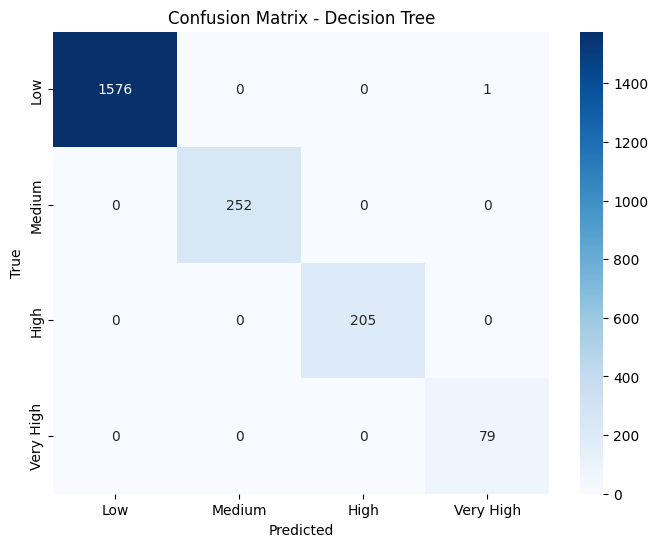

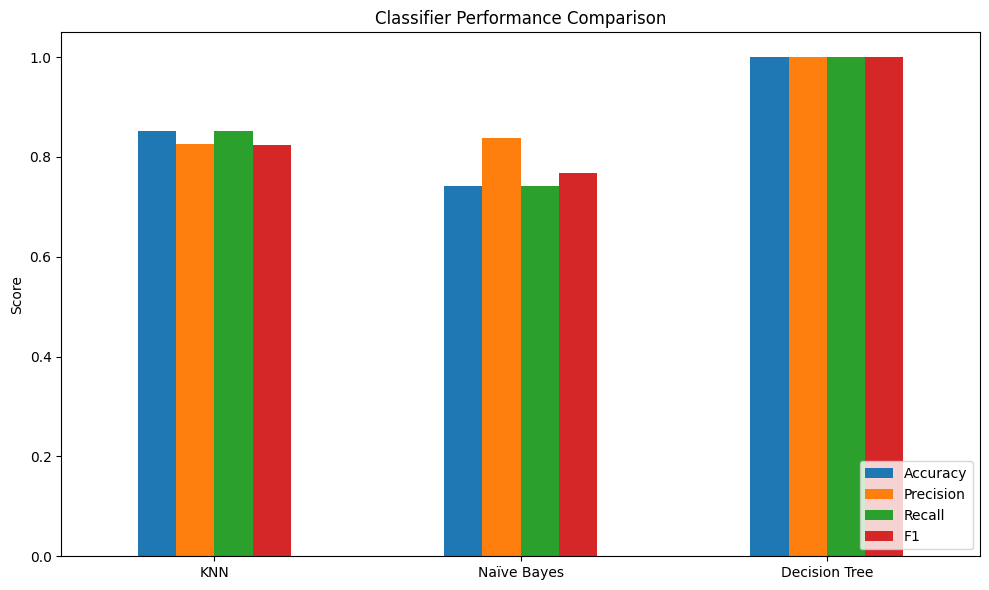

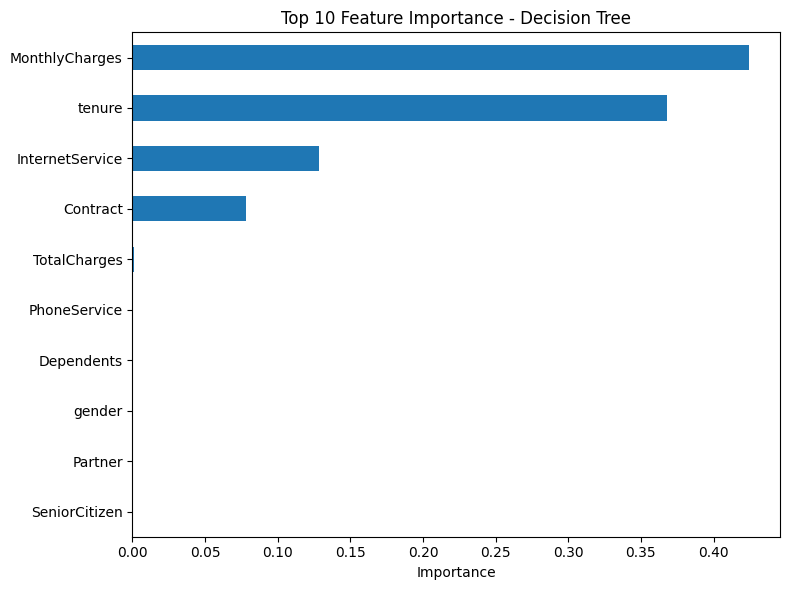

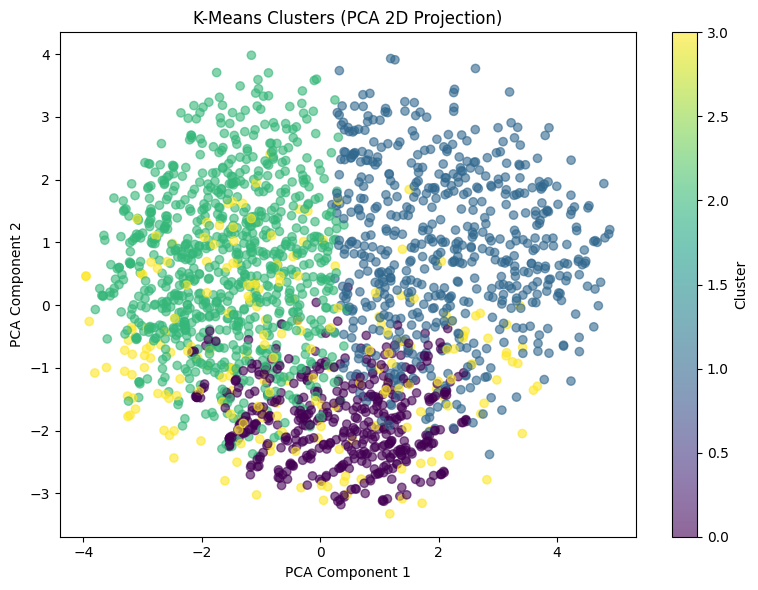

Algorithm Comparison:
               Accuracy  Precision    Recall        F1
KNN            0.850923   0.826207  0.850923  0.824700
Naïve Bayes    0.741126   0.837530  0.741126  0.767788
Decision Tree  0.999527   0.999533  0.999527  0.999528

K-Means Silhouette Score: 0.13455381107092917

Why Decision Tree:
Decision Trees are chosen for their interpretability, handling of non-linear relationships, and feature importance insights.

Improved Decision Tree Results:
Accuracy     0.999527
Precision    0.999533
Recall       0.999527
F1           0.999528
dtype: float64

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Load and preprocess dataset
df = pd.read_csv('telco_risk_levels.csv')
df = df.drop('customerID', axis=1)  # Drop non-predictive column
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])  # Encode categorical variables

# Define features and target
X = df.drop('RiskLevel', axis=1)
y = df['RiskLevel']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize results dictionary
results = {}

# 1. KNN Classification
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
results['KNN'] = {
    'Accuracy': accuracy_score(y_test, y_pred_knn),
    'Precision': precision_score(y_test, y_pred_knn, average='weighted'),
    'Recall': recall_score(y_test, y_pred_knn, average='weighted'),
    'F1': f1_score(y_test, y_pred_knn, average='weighted')
}

# 2. K-Means Clustering
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
kmeans.fit(X_train_scaled)
cluster_labels = kmeans.predict(X_test_scaled)
results['K-Means'] = {'Silhouette Score': silhouette_score(X_test_scaled, cluster_labels)}

# Print cluster distribution
print("K-Means Cluster Distribution (Test Set):")
print(pd.Series(cluster_labels).value_counts())

# 3. Naïve Bayes Classification
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
y_pred_nb = nb.predict(X_test_scaled)
results['Naïve Bayes'] = {
    'Accuracy': accuracy_score(y_test, y_pred_nb),
    'Precision': precision_score(y_test, y_pred_nb, average='weighted'),
    'Recall': recall_score(y_test, y_pred_nb, average='weighted'),
    'F1': f1_score(y_test, y_pred_nb, average='weighted')
}

# 4. Decision Tree Classification
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
results['Decision Tree'] = {
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt, average='weighted'),
    'Recall': recall_score(y_test, y_pred_dt, average='weighted'),
    'F1': f1_score(y_test, y_pred_dt, average='weighted')
}

# 5. Visualizations
# Confusion Matrix for Decision Tree
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'Medium', 'High', 'Very High'], yticklabels=['Low', 'Medium', 'High', 'Very High'])
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classifier Performance Comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
classifiers = ['KNN', 'Naïve Bayes', 'Decision Tree']
comparison_data = {metric: [results[clf][metric] for clf in classifiers] for metric in metrics}
comparison_df = pd.DataFrame(comparison_data, index=classifiers)
plt.figure(figsize=(10, 6))
comparison_df.plot(kind='bar', ax=plt.gca(), color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.title('Classifier Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Feature Importance for Decision Tree
plt.figure(figsize=(8, 6))
feature_importance = pd.Series(dt.feature_importances_, index=X.columns)
feature_importance.nlargest(10).sort_values().plot(kind='barh', color='#1f77b4')
plt.title('Top 10 Feature Importance - Decision Tree')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# K-Means Cluster Visualization (2D PCA)
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test_scaled)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6)
plt.title('K-Means Clusters (PCA 2D Projection)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

# 6. Algorithm Comparison and Decision Tree Rationale
comparison_df = pd.DataFrame({clf: {k: v for k, v in results[clf].items() if clf != 'K-Means'} for clf in ['KNN', 'Naïve Bayes', 'Decision Tree']}).T
print("Algorithm Comparison:")
print(comparison_df)
print("\nK-Means Silhouette Score:", results['K-Means']['Silhouette Score'])
print("\nWhy Decision Tree:")
print("Decision Trees are chosen for their interpretability, handling of non-linear relationships, and feature importance insights.")

# 7. Improve Decision Tree with Hyperparameter Tuning
param_grid = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='f1_weighted', n_jobs=1)
grid_search.fit(X_train_scaled, y_train)
best_dt = grid_search.best_estimator_
y_pred_best_dt = best_dt.predict(X_test_scaled)
improved_results = {
    'Accuracy': accuracy_score(y_test, y_pred_best_dt),
    'Precision': precision_score(y_test, y_pred_best_dt, average='weighted'),
    'Recall': recall_score(y_test, y_pred_best_dt, average='weighted'),
    'F1': f1_score(y_test, y_pred_best_dt, average='weighted')
}

print("\nImproved Decision Tree Results:")
print(pd.Series(improved_results))
print("\nBest Parameters:", grid_search.best_params_)